In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from scipy.stats import entropy
import copy
from tqdm import tqdm
import pickle
from datetime import datetime

import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('/Users/roberto/Desktop/PxPPM/main_code')))
from main_code.MCMCs import PxPPM
from main_code.visualization import plot_clusters, plot_superclusters

In [2]:
# Load the dataset
dataset = pd.read_hdf("/Users/roberto/Desktop/PxPPM/dataset/dataset.h5", key='dataset')

In [3]:
Y = np.vstack((dataset['EclipticLongitude'], dataset['EclipticLatitude'])).T
# Consider just the first 2 covariates
X = np.vstack((dataset['Cov1'], np.log10(dataset['Cov2']))).T

In [4]:
# Reduce the dataset size from 32713638 to 1000 observations
Y = Y[:1000]
X = X[:1000]

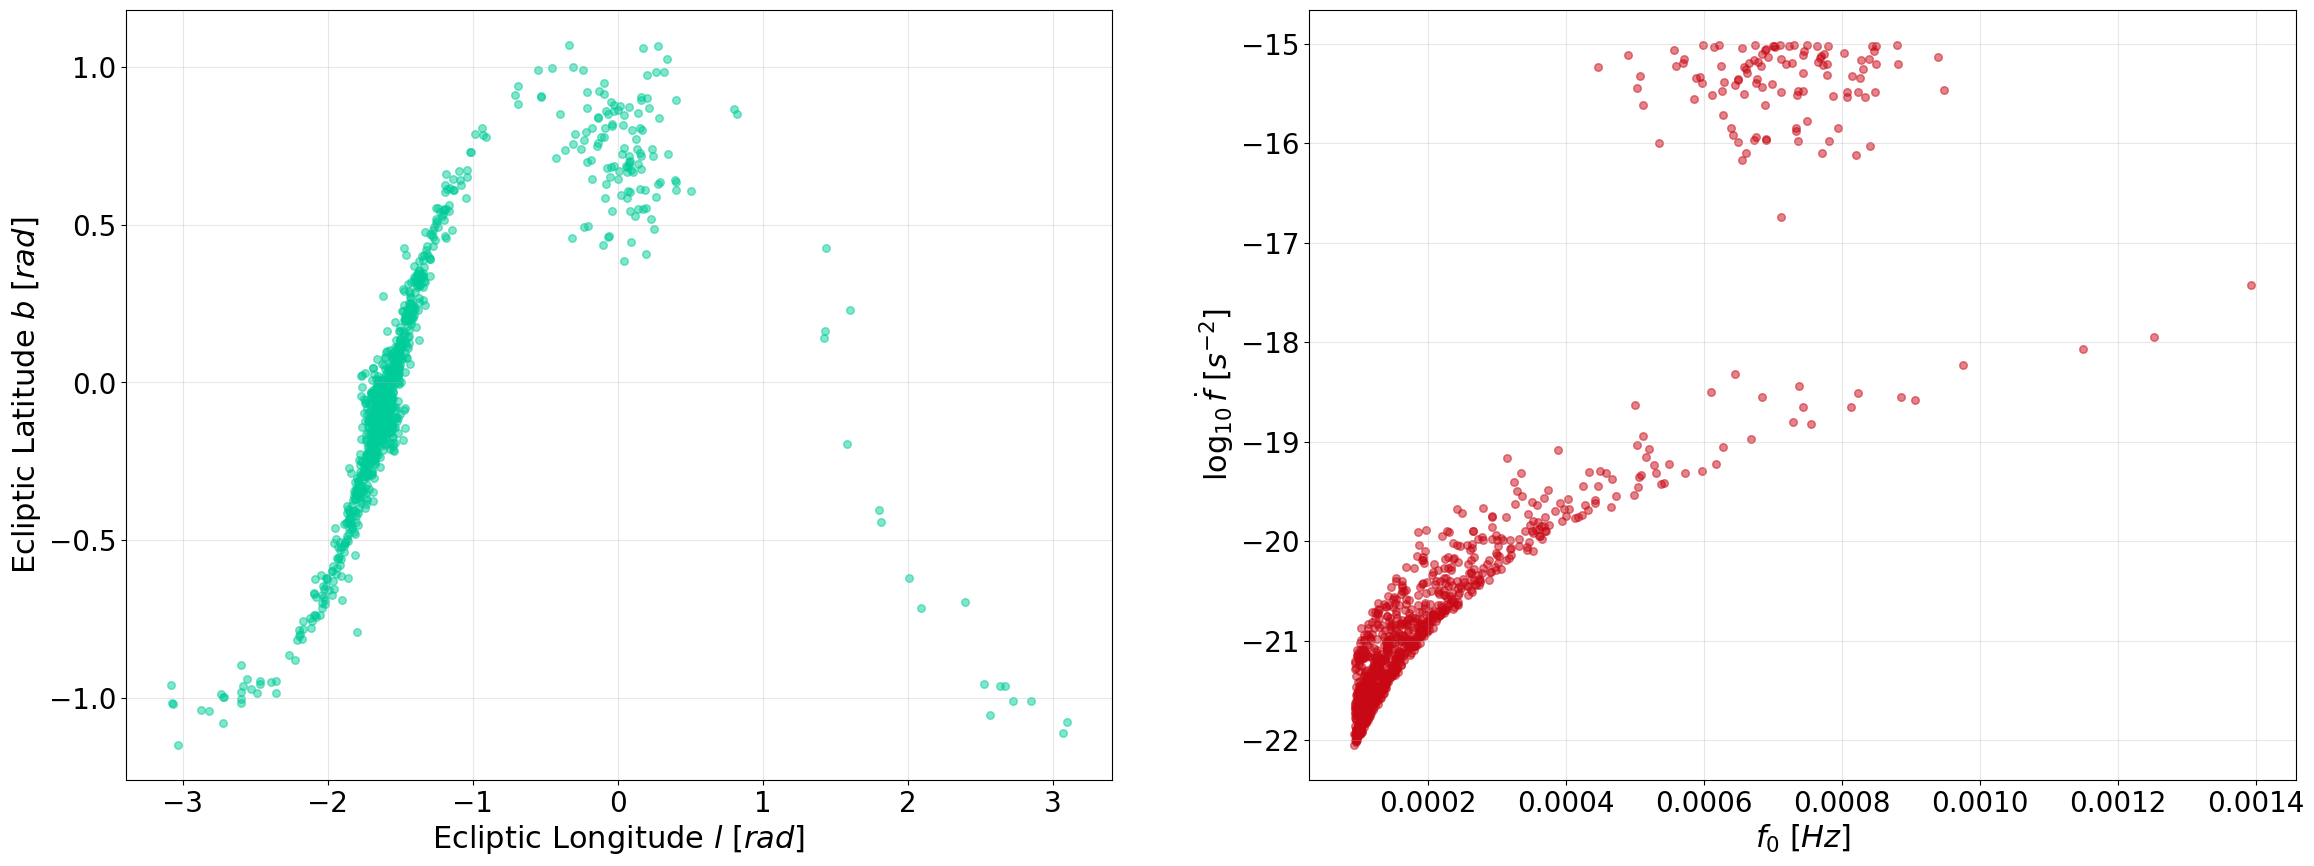

In [5]:
plt.figure(figsize=(28, 10))

plt.subplot(121)
plt.scatter(Y[:,0], Y[:,1], color="#00CC99", alpha=0.5, s=30)
plt.xlabel(rf"Ecliptic Longitude $l$ $[rad]$", fontsize = 22)
plt.ylabel(rf"Ecliptic Latitude $b$ $[rad]$",fontsize = 22)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(alpha=0.3)

plt.subplot(122)
plt.scatter(X[:,0], X[:,1], color="#C80815", alpha=0.5, s=30)
plt.xlabel(rf"$f_0$ $[Hz]$", fontsize = 22)
plt.ylabel(rf"$\log_{{10}} \dot{{f}}$ $[s^{{-2}}]$", fontsize = 22)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(alpha=0.3)

plt.show()



In [6]:
pxppm = PxPPM(alpha=0.1, lamb_0=1)

iter = 2000
sub_history, super_history = pxppm.fit(Y=Y, X=X, n_steps=iter)

PxPPM: 100%|██████████| 2000/2000 [49:33<00:00,  1.49s/it]  


In [8]:
best_subs, _ = pxppm.find_optimal_subclustering(burnin=250)
best_super_structure = pxppm.get_hierarchical_structure(best_subs, burnin=250)

Point Estimate Progress: 100%|██████████| 1751/1751 [13:46<00:00,  2.12step/s]


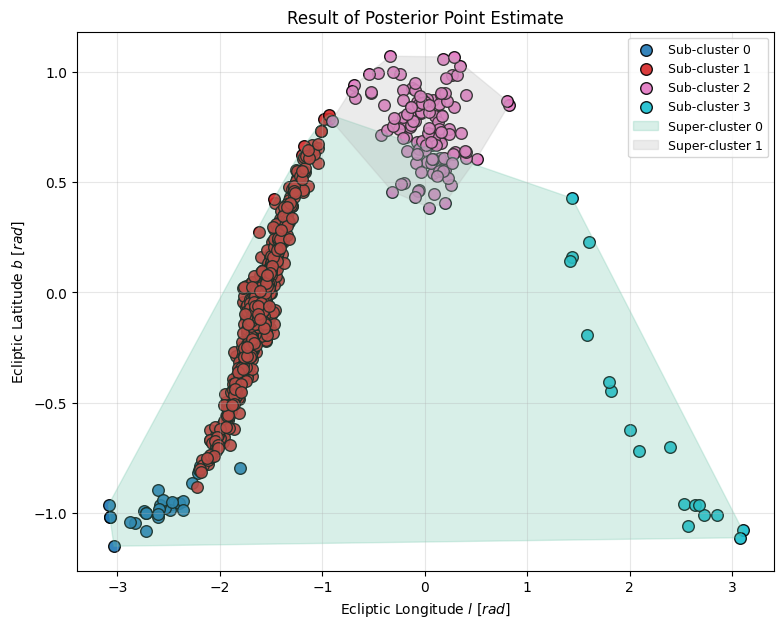

In [10]:
plot_superclusters(Y, best_subs, best_super_structure, "Result of Posterior Point Estimate", 
                  xlabel=rf"Ecliptic Longitude $l$ $[rad]$",
                  ylabel=rf"Ecliptic Latitude $b$ $[rad]$")

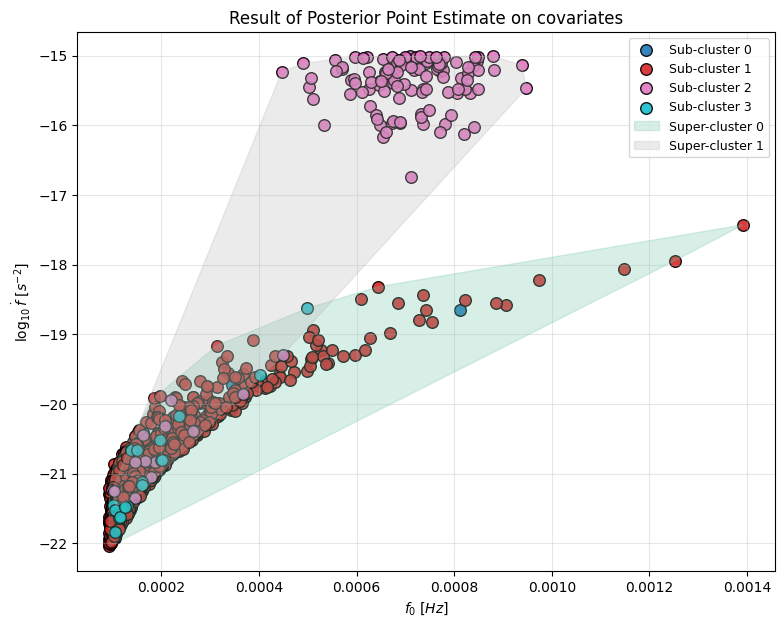

In [12]:
plot_superclusters(X, best_subs, best_super_structure, "Result of Posterior Point Estimate on covariates",
                   xlabel=rf"$f_0$ $[Hz]$", 
                   ylabel=rf"$\log_{{10}} \dot{{f}}$ $[s^{{-2}}]$")